In [244]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
disease=pd.read_parquet('/content/diseases.parquet')

### function to remove column spaces

In [246]:
def column_space_remove(columns_name):
    return columns_name.lower().replace(' ', '_')

In [247]:
disease.rename(columns=column_space_remove, inplace=True)

#### since there are too many rows with same disease but with different symptoms so keeping only 30 same diseases


In [248]:
disease['diseases'].value_counts()

,count
diseases,
cystitis,1219
nose disorder,1218
vulvodynia,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
open wound of the head,1
myocarditis,1
chronic ulcer,1


In [249]:
diseases=disease.copy()

In [250]:
# disease=disease[disease.groupby('diseases').cumcount() <30].reset_index(drop=True)

#### removing features that has low variance

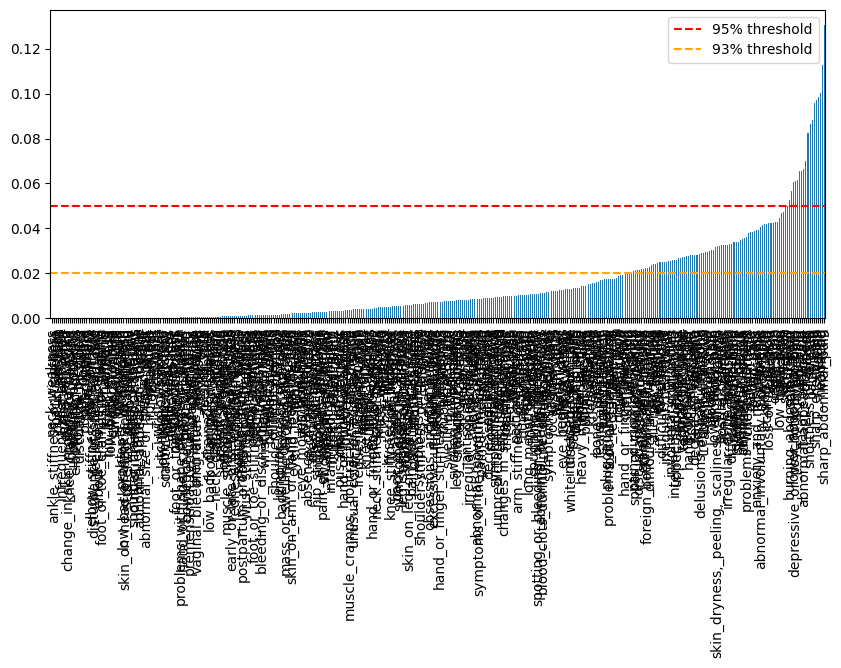

In [251]:
# Visualizing  variance of all features first
import matplotlib.pyplot as plt

variances = disease.mean(numeric_only=True).sort_values()  # mean = p for binary
variances.plot(kind='bar', figsize=(10, 4))
plt.axhline(0.05, color='red', linestyle='--', label='95% threshold')
plt.axhline(0.02, color='orange', linestyle='--', label='93% threshold')
plt.legend()
plt.show()

#### here removing data that has either 0 or 1 more than 93%

In [252]:
from sklearn.feature_selection import VarianceThreshold
numeric_cols=disease.select_dtypes(include='number').columns
string_cols=disease.select_dtypes(include='object').columns

selector=VarianceThreshold(threshold=0.03)
numeric_filtered=pd.DataFrame(selector.fit_transform(disease[numeric_cols]),columns=numeric_cols[selector.get_support()])

#### now concatating the filtered diseases

In [253]:
string_cols

Index(['diseases'], dtype='object')

In [254]:
disease = pd.concat([numeric_filtered, disease[string_cols].reset_index(drop=True)], axis=1)

#####  as we can see there is only 17 columns remain since other columns has high variance of 0 or 1 so they are removed

In [255]:
filtered_disease=disease.copy()

In [256]:
len(disease.columns)

55

In [257]:
print(disease['diseases'].nunique())   # how many unique classes
print(disease['diseases'].value_counts())

773
diseases
cystitis                          1219
nose disorder                     1218
vulvodynia                        1218
complex regional pain syndrome    1217
spondylosis                       1216
                                  ... 
open wound of the head               1
myocarditis                          1
chronic ulcer                        1
hypergammaglobulinemia               1
kaposi sarcoma                       1
Name: count, Length: 773, dtype: int64


#### here we can see there are more than 500 unique disease and this is too much for our project so taking top 30 diseases

In [258]:
top_diseases=disease['diseases'].value_counts().head(30).index

In [259]:
new_disease=disease[disease['diseases'].isin(top_diseases)].copy()

In [260]:
new_disease=new_disease.reset_index(drop=True)
new_disease

,anxiety_and_nervousness,depression,shortness_of_breath,depressive_or_psychotic_symptoms,sharp_chest_pain,dizziness,insomnia,abnormal_involuntary_movements,chest_tightness,sore_throat,...,loss_of_sensation,side_pain,fever,shoulder_pain,difficulty_breathing,coryza,itching_of_skin,"skin_dryness,_peeling,_scaliness,_or_roughness",skin_rash,diseases
0,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,acute pancreatitis
1,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,acute pancreatitis
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,acute pancreatitis
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,acute pancreatitis
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,acute pancreatitis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36359,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,eczema
36360,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,eczema
36361,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,eczema
36362,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,eczema


In [262]:
new_disease['diseases'].value_counts()

,count
diseases,
cystitis,1219
vulvodynia,1218
nose disorder,1218
complex regional pain syndrome,1217
spondylosis,1216
hypoglycemia,1215
esophagitis,1215
vaginal cyst,1215
conjunctivitis due to allergy,1215


##### separating features

In [263]:
X=new_disease.drop(columns=['diseases'])
y_raw=new_disease['diseases']

##### encoding diseases

In [264]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y_raw)


In [265]:
print("classes: ", le.classes_)

classes:  ['acute bronchitis' 'acute pancreatitis' 'arthritis of the hip'
 'benign prostatic hyperplasia (bph)' 'bursitis'
 'complex regional pain syndrome' 'conjunctivitis due to allergy'
 'cystitis' 'diverticulitis' 'eczema' 'esophagitis'
 'fungal infection of the hair' 'gastrointestinal hemorrhage' 'gout'
 'hypoglycemia' 'infectious gastroenteritis' 'injury to the arm'
 'injury to the leg' 'liver disease' 'marijuana abuse' 'nose disorder'
 'peripheral nerve disorder' 'pneumonia' 'spinal stenosis' 'spondylosis'
 'spontaneous abortion' 'sprain or strain' 'strep throat' 'vaginal cyst'
 'vulvodynia']


##### now splitting the dtaa into training and testing set

In [269]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [280]:
## training a xg_boost model
from xgboost import  XGBClassifier
n_classes=new_disease['diseases'].nunique()
model=XGBClassifier(
  num_class=n_classes,
  n_estimators=500,
  max_depth=6,
  learning_rate=0.01,
  random_state=42,
   n_jobs=-1
)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_class=30, ...)

In [281]:
### now checking if accuracy of model is good
from sklearn.metrics import classification_report,accuracy_score
y_pred=model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred):.4f}")
print(classification_report(y_test,y_pred,target_names=le.classes_))

Accuracy: 0.8097
                                    precision    recall  f1-score   support

                  acute bronchitis       0.70      0.81      0.75       243
                acute pancreatitis       0.86      0.82      0.84       241
              arthritis of the hip       0.87      0.88      0.87       242
benign prostatic hyperplasia (bph)       0.99      0.46      0.63       241
                          bursitis       0.85      0.83      0.84       242
    complex regional pain syndrome       0.78      0.68      0.72       244
     conjunctivitis due to allergy       0.98      0.97      0.97       243
                          cystitis       0.89      0.84      0.86       244
                    diverticulitis       0.94      0.64      0.76       243
                            eczema       0.81      0.98      0.89       241
                       esophagitis       0.94      0.92      0.93       243
      fungal infection of the hair       0.98      0.77      0.86     

In [ ]:
## saving model on cloab
import joblib
joblib.dump(model,'/content/disease_pred.pkl')
joblib.dump(le,'/content/label_encoder.pkl')
joblib.dump(list(X.columns),'/content/feature_cols.pkl')




['/content/feature_cols.pkl']